In [1]:
# Question 1: Radiative decay
# Task 1-3

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

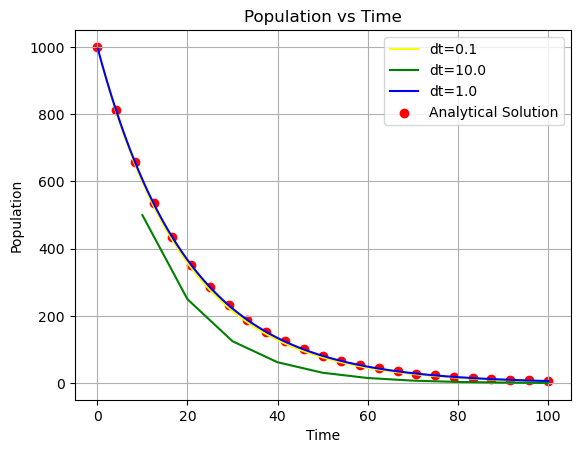

In [3]:
#second loop

dt = [1.0, 10, 0.1]      # Time Step (𝑑𝑡): 1.0 min, 10 min, and 0.1 min

for loop in range(3):
    dt[loop]
    N0 = 1000       # Initial Nuclei (𝑁0): 1000.....want this to change with respect to dt
    t = 0           # t=0 because we start at zero
    t_total = 100   # Total Time: 100 minutes
    lam = 0.05      # Decay Constant (λ): 0.05 min⁻¹

#list comes before the loop...moved inside the new loop for task 3
    t_list = []
    N0_list = []

# loop.... append inside the loop ....moved inside the new loop for task 3
    while t < t_total:
        delta_n = (-lam * N0)*dt[loop]
        t += dt[loop]
        N0 += delta_n  
        t_list.append(t)
        N0_list.append(N0)

    label_list = ["dt=0.1", "dt=10.0", "dt=1.0"]
    color_list = ["yellow", "green", "blue"]
    plt.plot(t_list, N0_list, color=color_list[loop], label=label_list[loop])

# np.linspace(start, stop, number of points)
t_array = np.linspace(0,100,25)

# make a function for task 2 analytical..... 𝑁(𝑡) = 𝑁0𝑒−λ𝑡
def analyt(N0, lam, t):
    return N0*np.exp(-lam*t)

N_anaylt = analyt(1000,0.05,t_array)
plt.scatter(t_array, N_anaylt, color = "red", label='Analytical Solution')      # analytical graph
plt.title("Population vs Time", fontsize = 12)
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.grid()

In [4]:
# Task 2: Verification

# Question: Does the simulation over-estimate or under-estimate the decay?
# Look closely at the first few steps.

print('The simulation follows closely along the decay of the graph. Since there is a constant slope with each step, the time step underestimates the decay.')

The simulation follows closely along the decay of the graph. Since there is a constant slope with each step, the time step underestimates the decay.


In [5]:
# Task 3: The Effect of the Time Step (dt)

# Question: How does the choice of dt affect the accuracy?
# Why can't we just set 𝑑𝑡 =1 × 10−12 to get a "perfect" answer?

print("The choice of dt affects the accuracy because a large dt assumes a faster, constant decay rate and under estimates the population.")
print("We cannot set '𝑑𝑡 =1 × 10−12' because it would introduce too much error. ")

The choice of dt affects the accuracy because a large dt assumes a faster, constant decay rate and under estimates the population.
We cannot set '𝑑𝑡 =1 × 10−12' because it would introduce too much error. 


In [6]:
# Task 4: Adding a "Source"

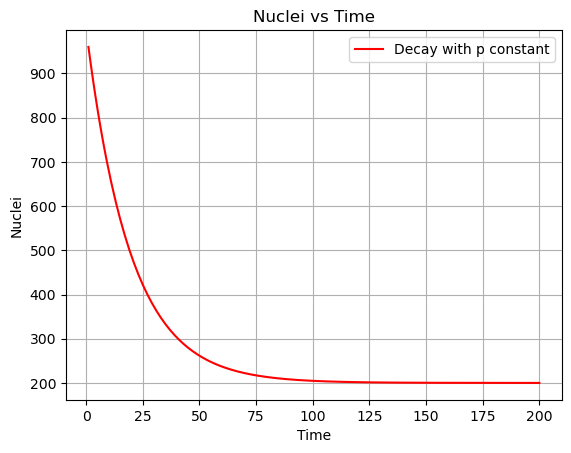

In [7]:
# modified code   // old equation 𝑑𝑁/𝑑𝑡 = −λ𝑁 // new equation 𝑑𝑁/𝑑𝑡 = 𝑃 -λ𝑁 //

p = 10          # P = 10 nuclei/min
dt = 1.0        # choose this time step...it follows the previous graph closely
N0 = 1000       # Initial Nuclei (𝑁0): 1000.....want this to change with respect to dt
t = 0           # t=0 because we start at zero
t_total = 200   # Total Time: 200 minutes
lam = 0.05      # Decay Constant (λ): 0.05 min⁻¹

#second loop no longer needed...keep lists
t_list = []
N0_list = []

# first loop
while t < t_total:
    delta_n = (p - (lam*N0))*dt
    t += dt
    N0 += delta_n  
    t_list.append(t)
    N0_list.append(N0)

plt.plot(t_list, N0_list, color = "red", label='Decay with p constant')
plt.title("Nuclei vs Time")
plt.xlabel("Time")
plt.ylabel("Nuclei")
plt.legend()
plt.grid()

In [8]:
# Questions:
# Does the population go to zero? Or does it reach a "Steady State"?
# If it reaches a steady state, calculate that value from your graph.

print("The population does not go to zero. The population reaches a steady state.")
print("The steady state is 200 nuclei.")

The population does not go to zero. The population reaches a steady state.
The steady state is 200 nuclei.


In [9]:
# Question 2: Projectile motion in 2D

# Task 1: The Vacuum Verification (2D Euler)

In [10]:
# initial conditions
v0 = 50                    # initial velocity ... meters/second
theta = np.radians(45)     # degrees to radians
g = 9.81                   # meters/second^2
t = 0                      # initial time... seconds
dt = 0.1                   # very small time step
vx = v0 *np.cos(theta)     # unit circle .. (x,y) becomes (cos,sin)
vy = v0 *np.sin(theta)
x = 0
y = 0

# create a list
x_list = []
y_list = []
t_list = []

# create a function for 𝑅 = 𝑣^2 * 𝑠𝑖𝑛(2𝜃) /𝑔
def theo_range(v0, theta, g):
    return ((v0**2)*(np.sin(2*theta))) / g

# first loop                        # if y is greater than or equal to zero >=
while y >= 0:                       # simulated
    #y_new = (y_old + v_old)*dt     simpler Euler method
    x += vx*dt
    y += vy*dt
    t += dt
    vy = vy -g*dt
    x_list.append(x)
    y_list.append(y)
    t_list.append(t)

simu_range = x_list[-1]
print(f"Simulated Range: {simu_range}" )
theoretical_range = theo_range(v0, theta, g)
print(f"Theoretical Range: {theoretical_range}" )

Simulated Range: 261.62950903902265
Theoretical Range: 254.841997961264


In [11]:
# Question: Is your simulation overshooting or undershooting? 

print("The simulation is overshooting.")

The simulation is overshooting.


In [12]:
# Task 2 Upgrading to Euler-Cromer

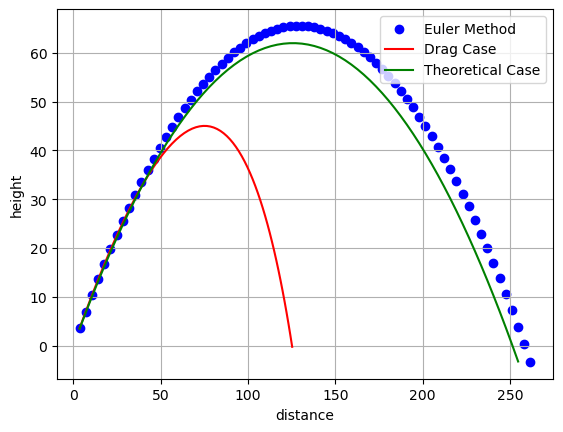

In [13]:
# initial conditions
v0 = 50                    # initial velocity ... meters/second
theta = np.radians(45)     # degrees to radians
g = 9.81                   # meters/second^2
t = 0                      # initial time... seconds
dt = 0.1                   # very small time step
vx = v0 *np.cos(theta)     # unit circle .. (x,y) becomes (cos,sin)
vy = v0 *np.sin(theta)
x = 0
y = 0
b = 0.2                    # task 2 add a linear drag force

# create a list
xsimu_list = []
ysimu_list = []
xtheo_list = []
ytheo_list = []
xeuler = []
yeuler = []

# create a function for 𝑅 = 𝑣^2 * 𝑠𝑖𝑛(2𝜃) /𝑔
def theo_range(v0, theta, g):
    return ((v0**2)*(np.sin(2*theta))) / g

# first loop       //    simulated   //  y_new = (y_old + v_old)*dt  //  simpler Euler method
while y >= 0:
    x += vx*dt
    y += vy*dt
    t += dt
    vy = vy + (-g -b*vy)*dt
    vx = vx + (-b*vx)*dt
    xsimu_list.append(x)
    ysimu_list.append(y)

# reset the loop
x, y, t = 0,0,0
vx = v0*np.cos(theta)
vy = v0*np.sin(theta)

# second loop    //    theoretical  //  y_new = (y_old + v_old)*dt  //  simpler Euler method
while y >= 0:
    x += vx*dt
    y += vy*dt
    t += dt
    vy = vy - g*dt
    #vx = vx - g*dt
    xtheo_list.append(x)
    ytheo_list.append(y)

# reset the loop
# euler loop
x, y, t = 0,0,0
vx = v0*np.cos(theta)
vy = v0*np.sin(theta)
while y >= 0:
    vy = vy - g*dt
    x += vx*dt
    y += vy*dt
    xeuler.append(x)
    yeuler.append(y)

# plot the graph
plt.scatter(xtheo_list, ytheo_list, color = "blue", label='Euler Method')
plt.plot(xsimu_list, ysimu_list, color = "red", label='Drag Case')
plt.plot(xeuler, yeuler, color = "green", label='Theoretical Case')
plt.xlabel("distance")
plt.ylabel("height")
plt.legend()
plt.grid()

In [14]:
# Question: How does air resistance affect the symmetry of the "arc"?

print("Air resistance affects the symmetry because it constantly reduces the horizontal velocity from the drag force. This causes the peak to be reached sooner in the drag case than the vacuum case.")

Air resistance affects the symmetry because it constantly reduces the horizontal velocity from the drag force. This causes the peak to be reached sooner in the drag case than the vacuum case.


In [15]:
# Task 3: Finding the New Optimal Angle

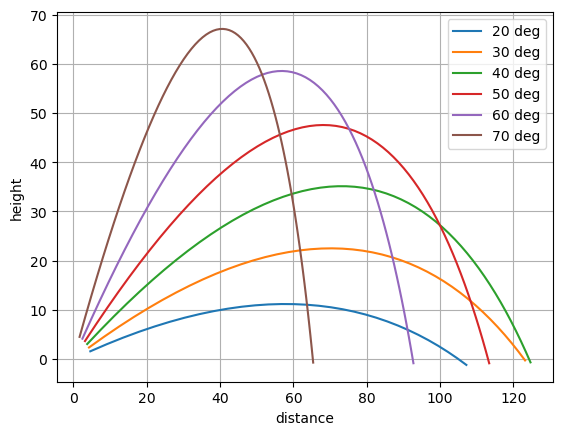

In [16]:
# finding the optimal angle theta
theta = [20,30,40,50,60,70]
labels = ["20 deg", "30 deg", "40 deg", "50 deg", "60 deg", "70 deg"]

plt.figure()

for opt_angle in range(6):
    new_theta = np.radians(theta[opt_angle])
    v0 = 50                    # initial velocity ... meters/second
    g = 9.81                   # meters/second^2
    dt = 0.1                   # very small time step
    vx = v0 *np.cos(new_theta)
    vy = v0 *np.sin(new_theta)
    x,y,t,b,m = 0, 0, 0, 0.2, 1
    # list inside the loop
    x_list2 = []
    y_list2 = []

    while y>=0:
        # vertical
        ay = -g - (b/m)*vy
        vy += + ay*dt
        y += vy*dt
        # horizontal
        ax = -(b/m)*vx
        vx += ax*dt 
        x += vx*dt
        t += dt
        #append next
        x_list2.append(x)
        y_list2.append(y)
    # plot overall within the loop
    plt.plot(x_list2, y_list2,label = labels[opt_angle])

# plot details here
plt.legend()
plt.xlabel("distance")
plt.ylabel("height")
plt.grid()

In [17]:
# Determine which angle provides the maximum horizontal distance.

print("The angle that provides the best horizontal distance is 40 degrees.")

The angle that provides the best horizontal distance is 40 degrees.


In [18]:
# Question 3: Newton's Law of Cooling

# Task 1: The Euler Baseline
# Task 2: The RK4 Upgrade
# Task 3: Comparison

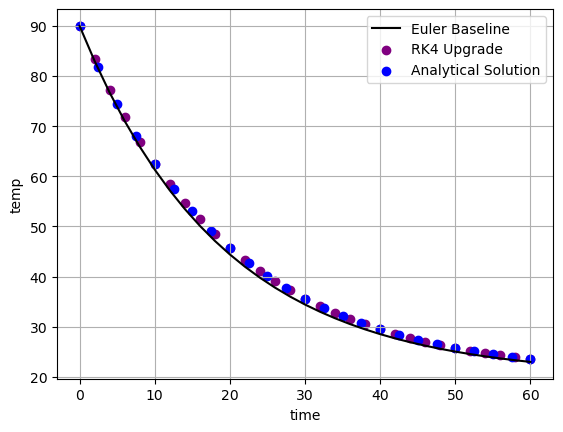

In [29]:
# 𝑑𝑇/𝑑𝑡 = − 𝐾(𝑇 − 𝑇𝑒𝑛𝑣)
# Runge-Kutta (RK4) method
# Plot the Analytical Solution (𝑇(𝑡) = 𝑇𝑒𝑛𝑣 + (𝑇0 − 𝑇𝑒𝑛𝑣)𝑒−𝐾𝑡)

# parameters
k = 0.05             # per 1 minute
dt = 2.0             # min (Purposefully large!)
t_time = 60          # total time in minutes
temp = 90            # initial degrees Celcius
t_env = 20           # ambient degrees Celcius (room temp)
t = 0                # initial time starts at 0

# create a list
time_euler_list = [t]
temp_euler_list = [temp]


while t < t_time:
    deltat = -k*(temp-t_env)      # delta t = change in t
    temp += deltat*dt
    t += dt
    time_euler_list.append(t)
    temp_euler_list.append(temp)

# RK4 UPGRADE
# new parameters ... same as old, but relabled
temp2 = 90
t_env2 = 20
k = 0.05               # still just a constant
dt2 = 2.0
t_time2 = 60
t2 = 0

# create a new list for RK4
timerk4_list = [t2]
temprk4_list = [temp2]

def temp_derivs(rk4_t,rk4_temp):
    return -k*(rk4_temp-t_env2)

# defining an rk4 function
def rk4_step(f, t2, y, dt2):
    """Standard RK4 integration step."""
    k1 = f(t2, y)
    k2 = f(t2+0.5*dt2, y + 0.5*dt2*k1)
    k3 = f(t2 + 0.5*dt2, y + 0.5*dt2*k2)
    k4 = f(t2+dt2, y + dt2*k3)
    return y + (dt2/6.0) * (k1 + 2*k2 + 2*k3 + k4)


# new loop for RK4
while t2 < t_time2:
    temp2 = rk4_step(temp_derivs, t2, temp2, dt2)
    t2 += dt2
    timerk4_list.append(t2)
    temprk4_list.append(temp2)

# task 3 Analytical Solution
# np.linspace(start, stop, number of points)
time3_list = np.linspace(0,60,25)
temp3_list = 20 + (90 - 20)*((np.e)**(-k*time3_list))

# plot the graphs
plt.plot(time_euler_list,temp_euler_list, color = "black", label = 'Euler Baseline')
plt.scatter(timerk4_list,temprk4_list, color="purple", label = 'RK4 Upgrade')
plt.scatter(time3_list, temp3_list, color="blue", label = 'Analytical Solution')
plt.legend()
plt.xlabel("time")
plt.ylabel("temp")
plt.grid()

In [28]:
# Questions:
# 1. With a large time step (dt = 2.0), which numerical method is closer to the exact solution?
# 2. Zoom in on the first 10 minutes. By roughly how many degrees Celsius is the Euler method off compared to RK4?

print("With a large time step dt=2.0, the numerical method RK4 points closer to the exact solution.")
print("The Euler method is off by roughly 2 degrees.")

With a large time step dt=2.0, the numerical method closer to the exact solution is the analytical curve.
The Euler method is off by roughly 1 degree.
